# Overview

## Dataset Overview

Oxford‑IIIT Pet contains 37 pet breeds with roughly 200 images per class, and images vary significantly in scale, pose, and lighting, which makes it a realistic benchmark for robust classification.​
In addition to images, the dataset ships with annotations including breed labels, species labels, segmentation masks, and head bounding boxes for the training split.

## Labels and Splits

TFDS exposes two official splits: 3,680 training examples and 3,669 test examples, for a total of 7,349 images.​
The feature dictionary includes image tensors, a 37‑class “label” (breed), a two‑class “species”, optional segmentation masks, and training‑only head bounding boxes, and for this project the target will be the two‑class“species"

## Install and import

In [1]:
!pip -q install tensorflow tensorflow-datasets
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import collections

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.9/319.9 kB 7.1 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-cloud-translate 3.12.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.19.5, but you have protobuf 5.29.5 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 46.0.3 which is incompatible.
pydrive2 1.21.3 requires pyOpenSSL<=24.2.1,>=19.1.0, but you have pyopenssl 25.3.0 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2025.1

2025-11-17 08:09:27.337009: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763366967.525528      48 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763366967.583269      48 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

- Images will be resized to 224×224 pixels (the size expected by VGG16).

- Data will be processed in batches of 32 images at a time.

In [3]:
ds_info = tfds.builder('oxford_iiit_pet').info
print("Species classes:", ds_info.features['species'].names)
print("Breed classes (#37):", ds_info.features['label'].names[:5], "...")

Species classes: ['Cat', 'Dog']
Breed classes (#37): ['Abyssinian', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle'] ...


- Loads dataset metadata without downloading images.

- The dataset has:

   - species: binary labels (['cat', 'dog'])

   - label: 37 breed categories (used for multi-class tasks).

- Printing confirms that you’re using the binary species feature.

In [4]:
def preprocess(example):
    image = tf.image.resize(example['image'], IMG_SIZE)
    image = tf.keras.applications.vgg16.preprocess_input(image)
    label = tf.cast(example['species'], tf.int32)
    return image, label

- Resizes each image to (224, 224).

- Preprocesses it using VGG16’s standard input format:

   - Converts RGB → BGR

    - Subtracts ImageNet mean pixel values

- Extracts label: species (0 for cat, 1 for dog).

- Returns (image, label) pairs.

In [5]:
splits = ['train[:85%]', 'train[85%:]', 'test']
train_raw, val_raw, test_raw = tfds.load('oxford_iiit_pet', split=splits, as_supervised=False)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

I0000 00:00:1763367037.994363      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1763367037.995284      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.E90HMO_4.0.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.E90HMO_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.


- The original dataset has a train and test split.

- From the train split:

  - First 85% → training set

  - Last 15% → validation set

- The test split → held-out final test set.

- as_supervised=False keeps the data in dictionary format (example['image'], example['species'], etc.).

In [6]:
train = (train_raw.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
         .shuffle(2048).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))
val = (val_raw.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
       .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))
test = (test_raw.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

- .map(preprocess): applies your preprocessing function to every example.

- .shuffle(2048): randomizes training data order for better generalization.

- .batch(BATCH_SIZE): groups samples into batches of 32.

- .prefetch(tf.data.AUTOTUNE): overlaps preprocessing with training for speed.

- These create optimized TensorFlow input pipelines.

In [7]:
species_names = ds_info.features['species'].names
def show_batch(ds, n=6):
    images, labels = next(iter(ds.unbatch().batch(n)))
    plt.figure(figsize=(12, 6))
    for i in range(n):
        plt.subplot(2, n//2, i+1)
        plt.imshow(tf.keras.utils.array_to_img(images[i]))
        plt.title(species_names[int(labels[i])])
        plt.axis('off')
    plt.show()

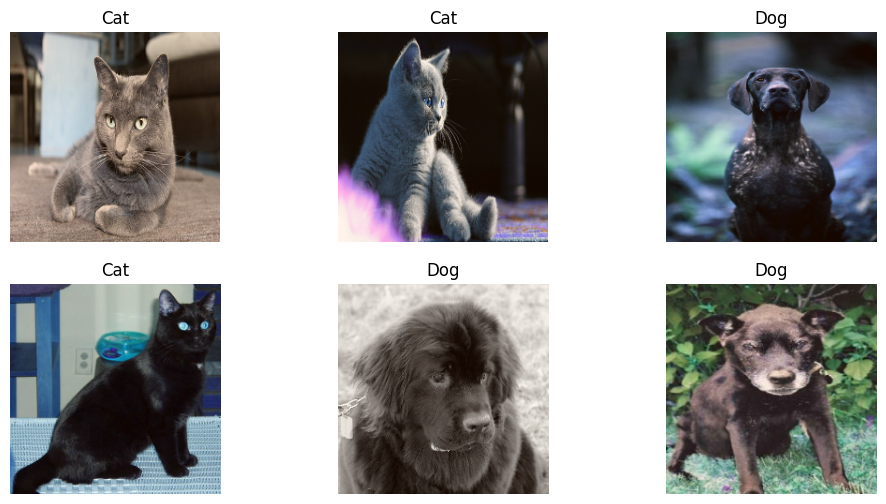

In [8]:
show_batch(train)

In [9]:
import collections
counter = collections.Counter()
for _, y in train.unbatch():  # sample to be quick
    counter[int(y)] += 1
print("Sampled species counts:", counter, "->", {species_names[k]: v for k, v in counter.items()})

Sampled species counts: Counter({1: 2132, 0: 996}) -> {'Dog': 2132, 'Cat': 996}


## Label Counts

Train set: {'Dog': 2132, 'Cat': 996}
Validation set: {'Dog': 360, 'Cat': 192}
Test set: {'Dog': 2486, 'Cat': 1183}


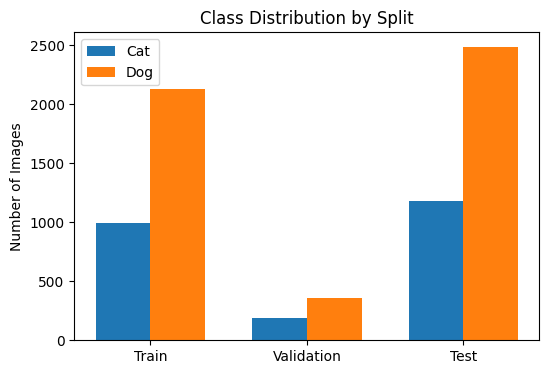

In [10]:
def count_classes(ds, name):
    counter = collections.Counter()
    for _, y in ds.unbatch():
        counter[int(y)] += 1
    print(f"{name} set:", {species_names[k].capitalize(): v for k, v in counter.items()})
    return counter  # <-- return added

train_counts = count_classes(train, "Train")
val_counts = count_classes(val, "Validation")
test_counts = count_classes(test, "Test")

species_names = ds_info.features['species'].names

# Extract counts
splits = ['Train', 'Validation', 'Test']
cat_counts = [train_counts.get(0, 0), val_counts.get(0, 0), test_counts.get(0, 0)]
dog_counts = [train_counts.get(1, 0), val_counts.get(1, 0), test_counts.get(1, 0)]

# Plot
x = range(len(splits))
width = 0.35

plt.figure(figsize=(6,4))
plt.bar([i - width/2 for i in x], cat_counts, width, label='Cat')
plt.bar([i + width/2 for i in x], dog_counts, width, label='Dog')
plt.xticks(x, splits)
plt.ylabel('Number of Images')
plt.title('Class Distribution by Split')
plt.legend()
plt.show()

## Why VGG16 and its preprocessing

VGG16 is a classic ImageNet‑pretrained model that expects 224×224 RGB inputs and specific channel preprocessing via vgg16.preprocess_input, making it simple and reliable for transfer learning on small to medium datasets.​
The standard transfer learning workflow is to freeze the pretrained convolutional base, train a lightweight classification head, then unfreeze the upper convolution blocks for low‑LR fine‑tuning to adapt features to the task.

In [11]:
from tensorflow.keras import models, layers
from tensorflow.keras.applications import VGG16
from tensorflow.keras import optimizers
import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array

In [12]:
base = VGG16(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
base.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


- Loads VGG16 pretrained on ImageNet.

- include_top=False → excludes the final classifier layers, leaving only convolutional feature extractor.

- base.trainable = False → freeze the weights so training doesn’t modify pretrained features initially.

In [13]:
data_aug = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

- Adds data augmentation to reduce overfitting:

  - Random horizontal flip

  - Random rotation (up to ±10%)

  - Random zoom

In [14]:
inputs = layers.Input(shape=(224,224,3))
x = data_aug(inputs)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model = models.Model(inputs, outputs)

- inputs → placeholder for 224×224 RGB images.

- Pass through augmentation, then VGG16 backbone.

- GlobalAveragePooling2D → converts convolutional feature maps into a 1D vector.

- Dropout(0.2) → prevents overfitting by randomly zeroing 20% of neurons.

- Dense(1, activation='sigmoid') → outputs a probability for dog vs cat.

- model → complete Keras Model object.

In [15]:
model.compile(optimizer=optimizers.Adam(1e-3),
              loss='binary_crossentropy',
              metrics=['accuracy'])

- Optimizer → Adam with learning rate 0.001.

- Loss → binary crossentropy (since it’s a 2-class problem).

- Metrics → track accuracy during training.

## Model Training

In [16]:
early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
ckpt = tf.keras.callbacks.ModelCheckpoint('vgg16_cats_dogs.keras', monitor='val_accuracy', mode='max', save_best_only=True)

history = model.fit(train, validation_data=val, epochs=20, callbacks=[early, ckpt], verbose=1)

Epoch 1/20


I0000 00:00:1763367085.059434     135 cuda_dnn.cc:529] Loaded cuDNN version 90300


98/98 ━━━━━━━━━━━━━━━━━━━━ 31s 208ms/step - accuracy: 0.7419 - loss: 1.0381 - val_accuracy: 0.9438 - val_loss: 0.1692
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 21s 176ms/step - accuracy: 0.9063 - loss: 0.2841 - val_accuracy: 0.9692 - val_loss: 0.0886
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 22s 183ms/step - accuracy: 0.9332 - loss: 0.2130 - val_accuracy: 0.9819 - val_loss: 0.0588
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 22s 187ms/step - accuracy: 0.9631 - loss: 0.1041 - val_accuracy: 0.9819 - val_loss: 0.0522
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 23s 198ms/step - accuracy: 0.9559 - loss: 0.1181 - val_accuracy: 0.9837 - val_loss: 0.0435
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 24s 209ms/step - accuracy: 0.9578 - loss: 0.1255 - val_accuracy: 0.9873 - val_loss: 0.0310
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 24s 205ms/step - accuracy: 0.9607 - loss: 0.1027 - val_accuracy: 0.9855 - val_loss: 0.0275
Epoch 8/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 23s 199ms/step - accuracy: 0.9673 - loss: 0.0953 - val_accuracy: 0.983

In [17]:
model.save('vgg16catsdogs.keras')
print("Model saved successfully.")

Model saved successfully.


- EarlyStopping: stops training if validation loss doesn’t improve for 3 epochs.

- ModelCheckpoint: saves the model weights with the best validation accuracy.

- history stores loss and accuracy per epoch for both train and validation sets.

**Quick guidance on reading curves**
- Healthy learning shows training and validation loss both decreasing, with validation accuracy rising and staying close to training accuracy across epochs.​

- If validation loss rises while training loss keeps falling, that indicates overfitting; consider EarlyStopping or data augmentation/fine‑tuning adjustments.

## Model Evaluation

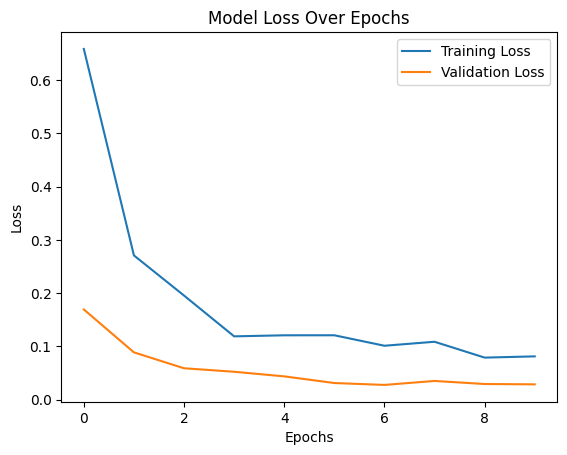

In [18]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss Over Epochs')     # Add a title
plt.xlabel('Epochs')                    # Label for x-axis
plt.ylabel('Loss')                      # Label for y-axis
plt.legend()                            # Show the legend
plt.show()

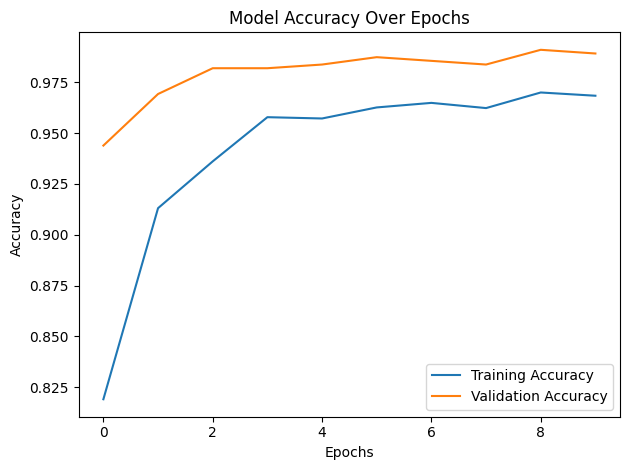

In [19]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()  # Adjust spacing between subplots
plt.show()

In [20]:
# Load the trained model
best_model = tf.keras.models.load_model('vgg16_cats_dogs.keras')

test_loss, test_acc = best_model.evaluate(test, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

115/115 ━━━━━━━━━━━━━━━━━━━━ 22s 188ms/step - accuracy: 0.9860 - loss: 0.0462
Test Loss: 0.0487
Test Accuracy: 0.9858


## Model Testing

In [21]:
pip install bcrypt==4.0.1 passlib==1.7.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 593.7/593.7 kB 10.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 525.6/525.6 kB 22.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [22]:
from fastapi import FastAPI, UploadFile, File, Depends, HTTPException
from fastapi.security import OAuth2PasswordBearer, OAuth2PasswordRequestForm
from passlib.context import CryptContext
from PIL import Image
import io
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import preprocess_input

app = FastAPI()

# Password hashing and token scheme setup (simple example)
pwd_context = CryptContext(schemes=["bcrypt"], deprecated="auto")
oauth2_scheme = OAuth2PasswordBearer(tokenUrl="token")

# Simple user DB for example (store hashed passwords in real apps)
fake_users_db = {
    "user": {"username": "user", "hashed_password": pwd_context.hash("pass")}
}

def verify_password(plain_password, hashed_password):
    return pwd_context.verify(plain_password, hashed_password)

def authenticate_user(username: str, password: str):
    user = fake_users_db.get(username)
    if not user or not verify_password(password, user["hashed_password"]):
        return False
    return user

@app.post("/token")
async def login(form_data: OAuth2PasswordRequestForm = Depends()):
    user = authenticate_user(form_data.username, form_data.password)
    if not user:
        raise HTTPException(status_code=400, detail="Incorrect username or password")
    # Generate a token - here we simply use username as token for demo purposes
    return {"access_token": user['username'], "token_type": "bearer"}

async def get_current_user(token: str = Depends(oauth2_scheme)):
    user = fake_users_db.get(token)
    if not user:
        raise HTTPException(status_code=401, detail="Invalid authentication credentials")
    return user

# Load the TensorFlow Keras model once at startup
model = tf.keras.models.load_model("vgg16catsdogs.keras")

@app.post("/predict")
async def predict(file: UploadFile = File(...), user: dict = Depends(get_current_user)):
    # Read and preprocess image
    image_bytes = await file.read()
    image = Image.open(io.BytesIO(image_bytes)).convert("RGB")
    image = image.resize((224, 224))
    img_array = np.array(image).astype(np.float32)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    # Make prediction
    preds = model.predict(img_array)
    confidence = float(preds[0][0])
    label = "Dog" if confidence > 0.5 else "Cat"
    confidence = confidence if confidence > 0.5 else 1 - confidence

    return {"label": label, "confidence": confidence}

In [29]:
!ngrok authtoken 33EQaovSQuTua0LUU3ns0lCs20Z_6yXKoXcNrW9DdYHKw9aze

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
!pip install fastapi uvicorn nest-asyncio pyngrok passlib[bcrypt] -q

import nest_asyncio
import uvicorn
from pyngrok import ngrok

nest_asyncio.apply()

public_url = ngrok.connect(8000)
print(f"Public URL: {public_url}")

uvicorn.run(app, host="0.0.0.0", port=8000)

Public URL: NgrokTunnel: "https://illatively-crackly-chuck.ngrok-free.dev" -> "http://localhost:8000"


INFO:     Started server process [48]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


INFO:     2400:1a00:3b4f:ef37:58a4:1e56:5f43:f8d:0 - "GET / HTTP/1.1" 404 Not Found
INFO:     2400:1a00:3b4f:ef37:58a4:1e56:5f43:f8d:0 - "GET /favicon.ico HTTP/1.1" 404 Not Found
INFO:     2400:1a00:3b4f:ef37:58a4:1e56:5f43:f8d:0 - "GET /docs HTTP/1.1" 200 OK
INFO:     2400:1a00:3b4f:ef37:58a4:1e56:5f43:f8d:0 - "GET /openapi.json HTTP/1.1" 200 OK


ERROR:asyncio:Task exception was never retrieved
future: <Task finished name='Task-1' coro=<Server.serve() done, defined at /usr/local/lib/python3.11/dist-packages/uvicorn/server.py:69> exception=KeyboardInterrupt()>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/uvicorn/main.py", line 580, in run
    server.run()
  File "/usr/local/lib/python3.11/dist-packages/uvicorn/server.py", line 67, in run
    return asyncio.run(self.serve(sockets=sockets))
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/nest_asyncio.py", line 30, in run
    return loop.run_until_complete(task)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/nest_asyncio.py", line 92, in run_until_complete
    self._run_once()
  File "/usr/local/lib/python3.11/dist-packages/nest_asyncio.py", line 133, in _run_once
    handle._run()
  File "/usr/lib/python3.11/asyncio/events.py", line 84, in _run
    se

INFO:     2400:1a00:3b4f:ef37:58a4:1e56:5f43:f8d:0 - "POST /token HTTP/1.1" 200 OK
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
INFO:     2400:1a00:3b4f:ef37:58a4:1e56:5f43:f8d:0 - "POST /predict HTTP/1.1" 200 OK
INFO:     27.34.66.116:0 - "POST /token HTTP/1.1" 200 OK
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
INFO:     27.34.66.116:0 - "POST /predict HTTP/1.1" 200 OK
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
INFO:     27.34.66.116:0 - "POST /predict HTTP/1.1" 200 OK
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
INFO:     27.34.66.116:0 - "POST /predict HTTP/1.1" 200 OK
INFO:     27.34.66.116:0 - "POST /token HTTP/1.1" 200 OK
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
INFO:     27.34.66.116:0 - "POST /predict HTTP/1.1" 200 OK
INFO:     27.34.66.116:0 - "POST /token HTTP/1.1" 200 OK
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
INFO:     27.34.66.116:0 - "POST /predict HTTP/1.1" 200 OK
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
INFO:     2400:1a00:3b4f:ef37:58a4:1e56:5f43:f8d:0 - "POST /predict HTTP/1.1" 200 OK
INFO:     27.3